Problem Statement

Retail and e-commerce decisions rely on accurate sales forecasting, but predicting future demand across regions and categories is complex.

Solution

A multi-model regression system that:

Filters data by region, category, segment
Engineers time-series features
Trains XGBoost and Random Forest
Selects best model (lowest MAE)
Forecasts sales up to 60 days
Provides visual insights and KPIs

 ML Pipeline 

1. **Data Cleaning**
   Remove irrelevant columns, parse dates, and sort by time

2. **Encoding**
   Apply Label Encoding to categorical features

3. **Data Filtering**
   Select data based on Region, Category, and Segment

4. **Feature Engineering**
   Create date features, lag variables, and rolling averages

5. **Model Selection**
   Evaluate **XGBoost** and **Random Forest** → choose lowest MAE

6. **Forecasting**
   Perform autoregressive predictions using lag & rolling features

7. **Output**
   Forecast results with charts, KPIs, and CSV export


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df = df.drop_duplicates()


In [5]:
df = df.drop(['Row ID','Order ID','Customer ID','Customer Name','Product ID','Product Name','City','Country','Postal Code','Ship Date'],axis = 1)

In [6]:
df['Order Date']= pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')


In [7]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['day'] = df['Order Date'].dt.day
df['day_of_week'] = df['Order Date'].dt.dayofweek

df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)


In [8]:
df['lag_1'] = df['Sales'].shift(1)
df['lag_7'] = df['Sales'].shift(7)
df['rolling_mean_7'] = df['Sales'].rolling(window=7).mean()
df['rolling_mean_14'] = df['Sales'].rolling(window=14).mean()

df = df.dropna()


In [9]:
df.head()
df.columns


Index(['Order Date', 'Ship Mode', 'Segment', 'State', 'Region', 'Category',
       'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'year',
       'month', 'day', 'day_of_week', 'is_weekend', 'lag_1', 'lag_7',
       'rolling_mean_7', 'rolling_mean_14'],
      dtype='object')

In [10]:
q1 = df['Sales'].quantile(0.25)
q3 = df['Sales'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df = df[(df['Sales'] >= lower) & (df['Sales'] <= upper)]


In [11]:
cat_cols = ['Ship Mode','Segment','State','Region','Category','Sub-Category']

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [12]:
df = df.sort_values('Order Date')
train_size = int (len(df)*0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]
                  


In [13]:
X_train = train.drop(['Sales','Order Date'], axis=1)
y_train = train['Sales']

X_test = test.drop(['Sales','Order Date'], axis=1)
y_test = test['Sales']


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf =RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [15]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)



In [16]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))

evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")




Random Forest
MAE: 23.561712744819054
RMSE: 44.36258340713888
R2: 0.8329039236972398

XGBoost
MAE: 24.883834617337104
RMSE: 43.23710521696507
R2: 0.8412748253637903


In [17]:
# ==========================
# BASELINE MODEL (IMPORTANT)
# ==========================

baseline_pred = X_test['lag_1']  # naive forecast

print("\nBaseline Model (Naive Forecast)")
print("MAE:", mean_absolute_error(y_test, baseline_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("R2:", r2_score(y_test, baseline_pred))



Baseline Model (Naive Forecast)
MAE: 221.46107913832202
RMSE: 576.8078080235696
R2: -27.248465127996575


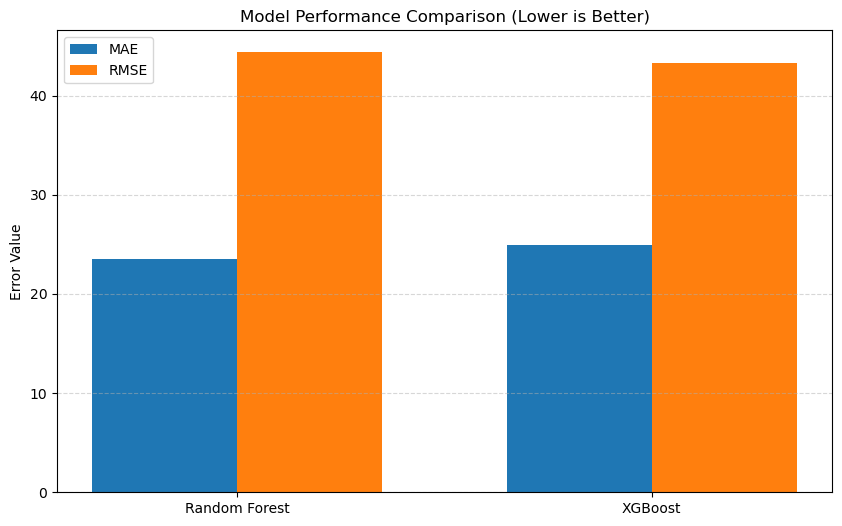

In [18]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Random Forest", "XGBoost"]

mae_values = [
    mean_absolute_error(y_test, rf_pred),
    mean_absolute_error(y_test, xgb_pred)
]

rmse_values = [
    np.sqrt(mean_squared_error(y_test, rf_pred)),
    np.sqrt(mean_squared_error(y_test, xgb_pred))
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))

# MAE bars
plt.bar(x - width/2, mae_values, width, label="MAE")

# RMSE bars
plt.bar(x + width/2, rmse_values, width, label="RMSE")

plt.xticks(x, models)
plt.ylabel("Error Value")
plt.title("Model Performance Comparison (Lower is Better)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


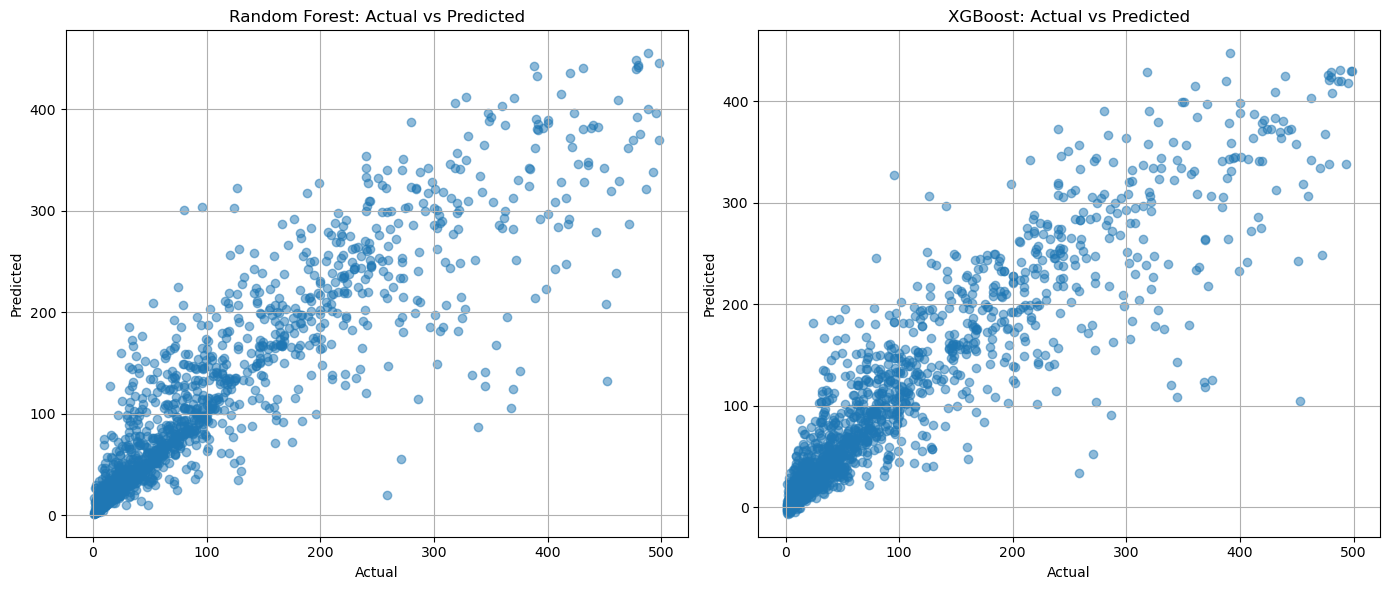

In [19]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(y_test, xgb_pred, alpha=0.5)
plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)

plt.tight_layout()
plt.show()


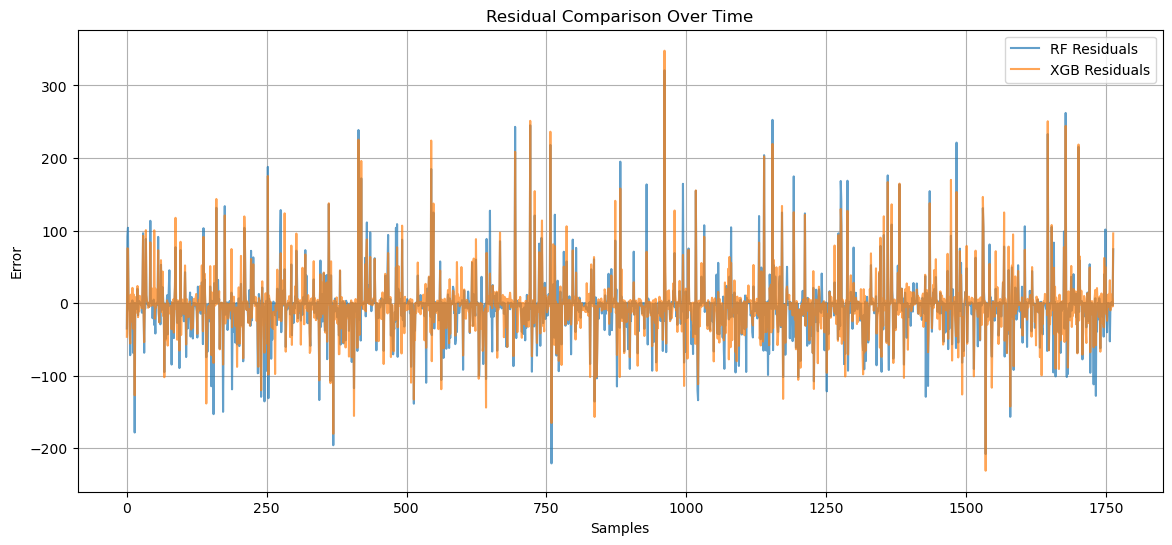

In [20]:
plt.figure(figsize=(14,6))

plt.plot((y_test.values - rf_pred), label="RF Residuals", alpha=0.7)
plt.plot((y_test.values - xgb_pred), label="XGB Residuals", alpha=0.7)

plt.title("Residual Comparison Over Time")
plt.xlabel("Samples")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# ==========================
# FIXED FUTURE FORECASTING
# ==========================

future_predictions = []

# start with last 7 actual values
history = df['Sales'].iloc[-7:].tolist()

last_row = df.iloc[-1:].copy()

for i in range(30):

    row = last_row.copy()

    # correct lag handling (NO leakage)
    row['lag_1'] = history[-1]
    row['lag_7'] = history[-7]

    # predict
    pred = xgb_model.predict(row.drop(['Sales','Order Date'], axis=1))[0]

    # store prediction
    future_predictions.append(pred)

    # update history safely
    history.append(pred)
    history = history[-7:]   # keep only last 7 values


In [22]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Business Drivers of Sales:")
print(importance.head(10))



Top Business Drivers of Sales:
            Feature  Importance
8            Profit    0.341849
7          Discount    0.170119
5      Sub-Category    0.121444
4          Category    0.096723
6          Quantity    0.055151
16   rolling_mean_7    0.027819
3            Region    0.022080
17  rolling_mean_14    0.018130
15            lag_7    0.017980
11              day    0.017715


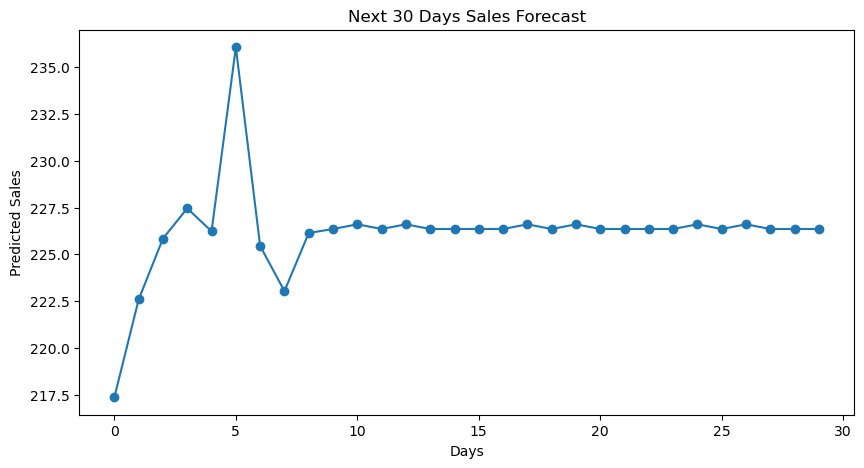

In [23]:
plt.figure(figsize=(10,5))
plt.plot(future_predictions, marker='o')
plt.title("Next 30 Days Sales Forecast")
plt.xlabel("Days")
plt.ylabel("Predicted Sales")
plt.show()


In [24]:
avg_forecast = np.mean(future_predictions)
trend = "increasing" if future_predictions[-1] > future_predictions[0] else "decreasing"

print("\n📊 BUSINESS INSIGHTS")
print("----------------------")
print(f"Average predicted sales: {avg_forecast:.2f}")
print(f"Trend: Sales are {trend}")
print(f"Peak forecast: {max(future_predictions):.2f}")
print(f"Lowest forecast: {min(future_predictions):.2f}")



📊 BUSINESS INSIGHTS
----------------------
Average predicted sales: 226.17
Trend: Sales are increasing
Peak forecast: 236.07
Lowest forecast: 217.36


In [25]:
import joblib
joblib.dump(rf, "random_forest.pkl")


['random_forest.pkl']

In [26]:
xgb_model.save_model("xgboost_model.json")
